# Pipeline completo — Detector de Plagio

Este notebook muestra cómo usar el pipeline de principio a fin:

```
archivos .py  →  ast_tokenizer  →  winnowing  →  features  →  build_pairs  →  model
```

> **Prerequisito:** la carpeta `pipeline/` debe estar en el mismo directorio que este notebook.

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '.')   # asegura que Python encuentre la carpeta pipeline/

from pipeline.ast_tokenizer import tokenize_file, tokenize_source
from pipeline.winnowing      import winnow, winnowing_similarity, fingerprint_jaccard
from pipeline.features       import compute_features, FEATURE_COLUMNS
from pipeline.build_pairs    import build_pairs_csv

import pandas as pd

---
## 1. Tokenizar un archivo individual

El primer paso del pipeline: convertir un `.py` en una secuencia de tokens normalizados.

In [2]:
resultado = tokenize_file("data/fibonacci__snip_01/original.py", masking="medium")

print("Tokens     :", resultado["tokens"])
print("Profundidad:", resultado["max_depth"])
print("Error      :", resultado["error"])     # None si todo fue bien

Tokens     : ['Module', 'FunctionDef', 'VAR', 'arguments', 'VAR', 'Assign', 'VAR', 'Store', 'List', 'LIT', 'LIT', 'Load', 'For', 'VAR', 'Store', 'Call', 'VAR', 'Load', 'LIT', 'VAR', 'Load', 'VAR', 'Load', 'LIT', 'VAR', 'Load', 'Expr', 'Call', 'Attribute', 'VAR', 'Load', 'VAR', 'Load', 'Load', 'BinOp', 'Subscript', 'VAR', 'Load', 'UnaryOp', 'USub', 'LIT', 'Load', 'Add', 'Subscript', 'VAR', 'Load', 'UnaryOp', 'USub', 'LIT', 'Load', 'Attribute', 'VAR', 'Load', 'VAR', 'Load', 'Load', 'BinOp', 'Subscript', 'VAR', 'Load', 'UnaryOp', 'USub', 'LIT', 'Load', 'Add', 'Subscript', 'VAR', 'Load', 'UnaryOp', 'USub', 'LIT', 'Load', 'Return', 'Subscript', 'VAR', 'Load', 'Slice', 'VAR', 'Load', 'Load']
Profundidad: 9
Error      : None


---
## 2. Generar huellas digitales (Winnowing)

A partir de los tokens, Winnowing produce un `frozenset` de hashes que representa la huella del archivo.

In [3]:
tokens = resultado["tokens"]

# k=15 y w=4: parámetros elegidos en la iteración 2 (los snippets tienen
# una mediana de ~73 tokens, k=23 de Dolos es demasiado largo aquí)
fingerprints = winnow(tokens, k=15, w=4)

print(f"Número de huellas : {len(fingerprints)}")
print(f"Primeras 5        : {sorted(fingerprints)[:5]}")

Número de huellas : 24
Primeras 5        : [87003172812975117, 861523324250130667, 1258454108439088356, 1344167841404367734, 1350598744168419869]


---
## 3. Comparar dos archivos

Calcula las 5 características para un par.

In [4]:
# ── Archivo A ──────────────────────────────────────────────
src_a = """
def reverse_string(s):
    result = ''
    for char in s:
        result = char + result
    return result
"""

# ── Archivo B (plagio de A: renombrado + código muerto) ────
src_b = """
def flip_str(text):
    out = ''
    unused_3 = 42
    for ch in text:
        out = ch + out
    return out
"""

K = 15

ra = tokenize_source(src_a, masking="medium")
rb = tokenize_source(src_b, masking="medium")

fps_a = winnow(ra["tokens"], k=K, w=4)
fps_b = winnow(rb["tokens"], k=K, w=4)

features = compute_features(
    ra["tokens"], ra["max_depth"], fps_a,
    rb["tokens"], rb["max_depth"], fps_b,
    k=K,
)

for nombre, valor in features.items():
    print(f"{nombre:30s}: {valor:.3f}")

winnowing_similarity          : 0.500
shared_fragment_coverage      : 0.754
token_overlap_ratio           : 0.333
ast_depth_difference          : 0.000
fingerprint_jaccard           : 0.333
small_kgram_jaccard           : 0.885
node_type_cosine              : 0.993
token_sequence_ratio          : 0.929
length_ratio                  : 0.867


---
## 4. Generar el CSV completo desde el dataset

Este es el paso principal: procesa todos los archivos del **dataset ad hoc** (grupos de plagio generados con `pipeline/generate_dataset.py` a partir del dataset de Kaggle) y genera `pairs_features.csv`.

In [5]:
# Si la carpeta data/ no existe, primero generar el dataset ad hoc:
#   python -m pipeline.generate_dataset --output-dir data --variants 4
build_pairs_csv(
    data_dir = "data",
    output   = "pairs_features.csv",
    k        = 15,
    w        = 4,
    masking  = "medium",
    verbose  = False,
)

WindowsPath('pairs_features.csv')

---
## 5. Inspeccionar el CSV generado

In [6]:
df = pd.read_csv("pairs_features.csv")

print(f"Filas totales : {len(df)}")
print(f"Positivos     : {(df.label == 1).sum()}")
print(f"Negativos     : {(df.label == 0).sum()}")
print()
df.head(10)

Filas totales : 2000
Positivos     : 1000
Negativos     : 1000



,winnowing_similarity,shared_fragment_coverage,token_overlap_ratio,ast_depth_difference,fingerprint_jaccard,small_kgram_jaccard,node_type_cosine,token_sequence_ratio,length_ratio,label,file_a,file_b
0,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1,data\max_in_list__snip_20\variant_1.py,data\max_in_list__snip_20\variant_3.py
1,0.125000,0.229820,0.053892,0.000000,0.049180,0.216000,0.946092,0.500000,0.758621,0,data\fibonacci__snip_13\variant_3.py,data\fibonacci__snip_17\variant_4.py
2,0.777778,0.879898,0.609756,0.000000,0.617647,0.700000,0.998512,0.969925,0.970370,1,data\is_prime__snip_08\variant_2.py,data\is_prime__snip_08\variant_4.py
3,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1,data\reverse_string__snip_01\variant_2.py,data\reverse_string__snip_01\variant_3.py
4,0.000000,0.000000,0.000000,0.100000,0.000000,0.055556,0.926302,0.387755,0.606557,0,data\is_palindrome__snip_10\original.py,data\max_in_list__snip_09\variant_1.py
5,0.000000,0.000000,0.000000,0.200000,0.000000,0.027397,0.801487,0.134831,0.160870,0,data\max_in_list__snip_13\original.py,data\is_palindrome__snip_07\variant_4.py
6,0.000000,0.000000,0.000000,0.111111,0.000000,0.108696,0.958065,0.546667,1.000000,0,data\fibonacci__snip_03\variant_1.py,data\max_in_list__snip_20\variant_1.py
7,0.000000,0.000000,0.000000,0.200000,0.000000,0.102941,0.924059,0.575342,1.000000,0,data\reverse_string__snip_19\variant_3.py,data\reverse_string__snip_12\variant_4.py
8,0.757895,0.924493,0.574751,0.000000,0.595041,0.700637,0.999057,0.963731,0.949495,1,data\fibonacci__snip_09\original.py,data\fibonacci__snip_09\variant_4.py
9,0.156250,0.525992,0.072368,0.307692,0.079365,0.291262,0.933175,0.579365,0.774648,0,data\is_prime__snip_13\variant_4.py,data\is_prime__snip_05\variant_4.py


In [7]:
# Estadísticas por clase: los positivos deben tener valores altos en las
# métricas de similitud y bajo en ast_depth_difference
df.groupby("label")[FEATURE_COLUMNS].mean().round(3)

,winnowing_similarity,shared_fragment_coverage,token_overlap_ratio,ast_depth_difference,fingerprint_jaccard,small_kgram_jaccard,node_type_cosine,token_sequence_ratio,length_ratio
label,,,,,,,,,
0,0.028,0.050,0.016,0.167,0.017,0.128,0.909,0.430,0.596
1,0.807,0.891,0.725,0.001,0.719,0.856,0.996,0.961,0.960


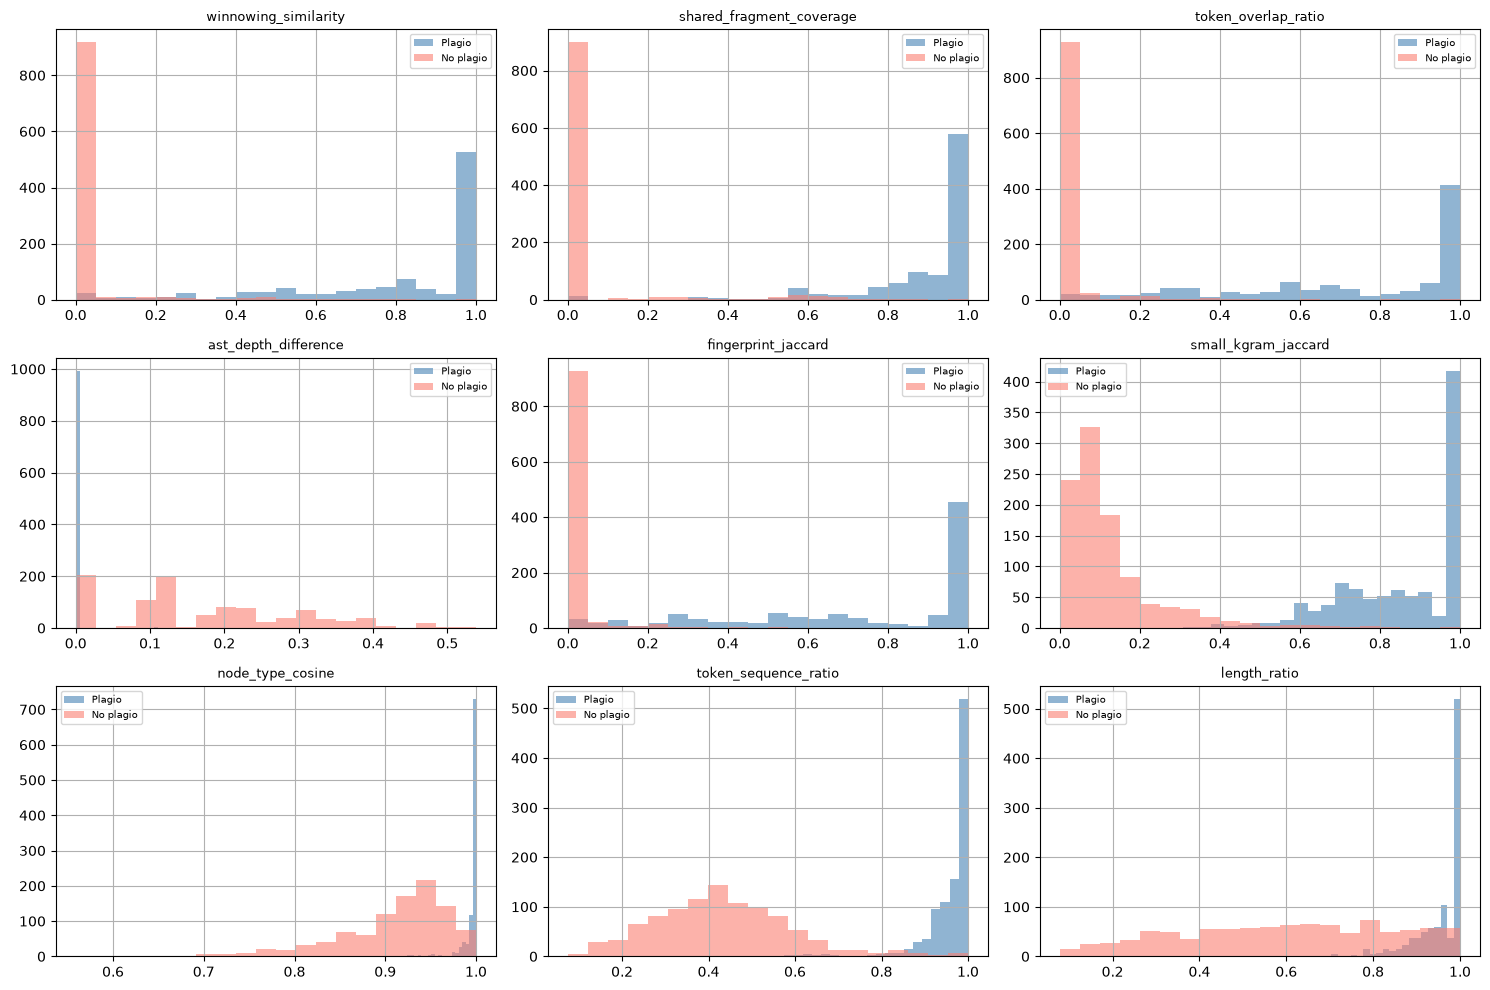

In [8]:
# Distribución de cada característica por clase
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, col in zip(axes.ravel(), FEATURE_COLUMNS):
    for label, color, name in [(1, "steelblue", "Plagio"), (0, "salmon", "No plagio")]:
        df[df.label == label][col].hist(ax=ax, alpha=0.6, bins=20,
                                        color=color, label=name)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

---
## 6. Entrenar el modelo

Con el CSV listo, abre `model.ipynb` y ejecútalo.
Detecta `pairs_features.csv` automáticamente y entrena con los datos reales.

O bien ejecuta las celdas del modelo directamente aquí:

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

RANDOM_SEED = 42
LABEL_COLUMN = "label"
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

x = df[FEATURE_COLUMNS].values.astype("float32")
y = df[LABEL_COLUMN].values.astype("float32")

x_train_full, x_test, y_train_full, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2,
    stratify=y_train_full, random_state=RANDOM_SEED,
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val   = scaler.transform(x_val)
x_test  = scaler.transform(x_test)

model = keras.Sequential([
    layers.Input(shape=(len(FEATURE_COLUMNS),)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1,  activation="sigmoid"),
])
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")],
)

model.fit(x_train, y_train, epochs=100, batch_size=32,
          validation_data=(x_val, y_val),
          callbacks=[keras.callbacks.EarlyStopping(
              monitor="val_loss", patience=10, restore_best_weights=True)],
          verbose=0)

# Umbral que maximiza F1 en validación (protocolo del marco, sección 8.2)
val_probs = model.predict(x_val, verbose=0).ravel()
ths = np.linspace(0.05, 0.95, 91)
f1s = np.array([f1_score(y_val, val_probs >= t) for t in ths])
# Si varios umbrales empatan en F1 maximo, elegir el mas cercano a 0.5
cands = ths[f1s >= f1s.max() - 1e-9]
best_threshold = float(cands[np.argmin(np.abs(cands - 0.5))])

test_probs = model.predict(x_test, verbose=0).ravel()
y_pred = (test_probs >= best_threshold).astype(int)

print(f"Umbral de decisión : {best_threshold:.2f}")
print("\n── Resultados en test ──")
print(f"  precision : {precision_score(y_test, y_pred):.3f}")
print(f"  recall    : {recall_score(y_test, y_pred):.3f}")
print(f"  f1        : {f1_score(y_test, y_pred):.3f}")
print(f"  auc       : {roc_auc_score(y_test, test_probs):.3f}")

Umbral de decisión : 0.12

── Resultados en test ──
  precision : 0.971
  recall    : 0.990
  f1        : 0.980
  auc       : 0.999


---
## 7. Usar el modelo para predecir un par nuevo

In [10]:
def predict_pair(path_a: str, path_b: str, k: int = 15, w: int = 4,
                 masking: str = "medium", threshold: float | None = None) -> dict:
    """Dado dos archivos .py, devuelve la probabilidad de plagio."""
    threshold = best_threshold if threshold is None else threshold
    ra = tokenize_file(path_a, masking=masking)
    rb = tokenize_file(path_b, masking=masking)

    fps_a = winnow(ra["tokens"], k=k, w=w)
    fps_b = winnow(rb["tokens"], k=k, w=w)

    feats = compute_features(
        ra["tokens"], ra["max_depth"], fps_a,
        rb["tokens"], rb["max_depth"], fps_b,
        k=k,
    )

    x_new = scaler.transform([[feats[c] for c in FEATURE_COLUMNS]])
    prob  = float(model.predict(x_new, verbose=0)[0][0])

    return {
        "probabilidad_plagio": round(prob, 4),
        "veredicto"          : "PLAGIO" if prob >= threshold else "NO PLAGIO",
        "features"           : {k_: round(v, 4) for k_, v in feats.items()},
    }


# Par plagiado: original y su variante ofuscada (mismo grupo)
caso_plagio = predict_pair(
    "data/fibonacci__snip_01/original.py",
    "data/fibonacci__snip_01/variant_4.py",
)
# Par NO plagiado: mismo problema, algoritmo distinto (negativo difícil)
caso_limpio = predict_pair(
    "data/fibonacci__snip_01/original.py",
    "data/fibonacci__snip_02/original.py",
)

for titulo, res in [("original vs variante ofuscada", caso_plagio),
                    ("mismo problema, otro algoritmo", caso_limpio)]:
    print(f"── {titulo} ──")
    print(f"  Veredicto           : {res['veredicto']}")
    print(f"  Probabilidad plagio : {res['probabilidad_plagio']}")
    print()

── original vs variante ofuscada ──
  Veredicto           : PLAGIO
  Probabilidad plagio : 0.9921

── mismo problema, otro algoritmo ──
  Veredicto           : NO PLAGIO
  Probabilidad plagio : 0.0

